In [2]:
print("hello")

hello


In [17]:
from typing import TypedDict, List, Dict, Any, Literal
from pydantic import BaseModel, Field
import time

from langchain_core.documents import Document
from langchain_community.document_loaders import PyPDFLoader,PyPDFDirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
import os



In [5]:

load_dotenv()

OPENROUTER_API_KEY=os.getenv("OPENROUTER_API_KEY")
os.environ["OPENROUTER_API_KEY"]=OPENROUTER_API_KEY

model= ChatOpenAI( base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
    model= "nvidia/nemotron-3-nano-30b-a3b:free"
)
model.invoke("hello")

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 17, 'total_tokens': 46, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 21, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'nvidia/nemotron-3-nano-30b-a3b:free', 'system_fingerprint': None, 'id': 'gen-1771930170-fXCEoVP6IY6ekmNDrQZC', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c8f44-abb3-7162-a37c-580909e7eb44-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 29, 'total_tokens': 46, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_detai

In [9]:
dir_path = "./documents"

loader=PyPDFDirectoryLoader(
    path= dir_path,
    glob= "**/*.pdf",
)

docs= loader.load()

In [10]:
docs[:3]

[Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'documents\\Company_Policies.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='NexaAI Solutions – Company Policies\nHR Policies\nNexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.\nAll employment decisions are made without discrimination.\n\x7f\nEqual opportunity employer\n\x7f\nBi-annual performance reviews\n\x7f\nClear career progression framework\n\x7f\nStrict anti-harassment policy\nLeave Policy\nEmployees are encouraged to maintain a healthy work-life balance.\n\x7f\nAnnual Leave: 18 working days per year\n\x7f\nSick Leave: 10 working days per year\n\x7f\nCasual Leave: 6 working days per year\n\x7f\nMaternity Leave: A

In [11]:
chunks = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200).split_documents(docs)
chunks[:3]

[Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'documents\\Company_Policies.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='NexaAI Solutions – Company Policies\nHR Policies\nNexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.\nAll employment decisions are made without discrimination.\n\x7f\nEqual opportunity employer\n\x7f\nBi-annual performance reviews\n\x7f\nClear career progression framework\n\x7f\nStrict anti-harassment policy\nLeave Policy\nEmployees are encouraged to maintain a healthy work-life balance.\n\x7f\nAnnual Leave: 18 working days per year\n\x7f\nSick Leave: 10 working days per year\n\x7f\nCasual Leave: 6 working days per year\n\x7f\nMaternity Leave: A

In [15]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': False})

vectorstore = FAISS.from_documents(documents=chunks,
                                embedding=embeddings)

retriever = vectorstore.as_retriever(search_kwargs={'k':3})

In [16]:
retriever.invoke("what is company name")

[Document(id='2ce215c6-e314-4211-b9b8-a0e303ac3a21', metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'documents\\Company_Profile.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='NexaAI Solutions – Company Profile\nCompany Overview\nNexaAI Solutions Pvt. Ltd. is a business-focused artificial intelligence company founded in 2021.\nThe company specializes in building enterprise-ready AI systems for knowledge management,\nanalytics, and automation.\nNexaAI primarily serves mid-sized and large organizations across technology, finance, healthcare,\nand education sectors.\n\x7f\nFounded: 2021\n\x7f\nHeadquarters: Bengaluru, India\n\x7f\nEmployees: 85+\n\x7f\nOperating Regions: India, Southeast Asia, Europe\nVision\nTo bec

In [20]:
class State(TypedDict):
    question :str
    need_retrieval : bool
    docs : List[Document]
    answer :str
    

In [58]:
class RetrieveDecision(BaseModel):
     should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

# IMPORTANT: no `.content` for structured output
should_retrieve_llm = model.with_structured_output(RetrieveDecision)

def decide_retrieval(state : State):
    decision : RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
        
    )
    
    return {'need_retrieval': decision.should_retrieve}

In [49]:
decide_retrieval({'question':'what is machine learinig'})

False


d:\Vaibhav_PC\GenerativeAI\GI\Advance_RAG\Campus_RAG\Self_RAG\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RetrieveDecision(should_retrieve=False), input_type=RetrieveDecision])
  return self.__pydantic_serializer__.to_python(


{'need_retrieval': False}

In [55]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)

def generate_direct(state:State):
    out = model.invoke(
        direct_generation_prompt.format_messages(question=state['question'])
    )
    return {'answer':out.content}

In [40]:
def retrieve(state:State):
    return {'docs': retrieve.invoke(state['question'])}


In [52]:
def route_after_decide(state:State):
    if state['need_retrieval']:
        return 'retrieve'
    return "generate_direct"

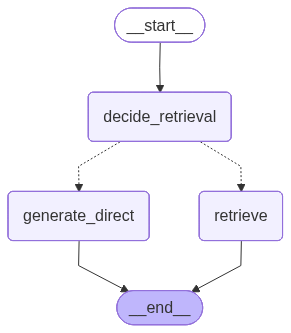

In [56]:
g = StateGraph(State)
g.add_node('decide_retrieval',decide_retrieval)
g.add_node('generate_direct',generate_direct)
g.add_node('retrieve',retrieve)

g.add_edge(START,'decide_retrieval')
g.add_conditional_edges('decide_retrieval',route_after_decide,
                        {'generate_direct':"generate_direct",
                        'retrieve':"retrieve"}
                        )
g.add_edge('generate_direct',END)
g.add_edge('retrieve',END)

app=g.compile()
app

In [57]:
result = app.invoke({
    'question': "what is Machine Learning",
    'need_retrieval':False,
    'docs' :[],
    'answer' : str}
)

result

d:\Vaibhav_PC\GenerativeAI\GI\Advance_RAG\Campus_RAG\Self_RAG\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RetrieveDecision(should_retrieve=False), input_type=RetrieveDecision])
  return self.__pydantic_serializer__.to_python(


False


{'question': 'what is Machine Learning',
 'need_retrieval': False,
 'docs': [],
 'answer': 'Machine learning is a branch of artificial intelligence that focuses on developing algorithms and statistical models that enable computers to perform tasks without being explicitly programmed for each specific instruction. Instead of following a fixed set of rules, a machine‑learning system learns patterns from data, builds its own internal model, and then uses that model to make predictions, classify information, or make decisions. The process typically involves:\n\n1. **Collecting data** – gathering examples relevant to the problem (e.g., images, text, sensor readings, financial records).  \n2. **Training a model** – feeding the data into an algorithm that adjusts its internal parameters to capture the underlying patterns (common approaches include linear regression, decision trees, neural networks, etc.).  \n3. **Evaluating performance** – testing the trained model on unseen data to see how w

In [59]:
result = app.invoke({
    'question': "what is Machine Learning",}
   
)

result

False


{'question': 'what is Machine Learning',
 'need_retrieval': False,
 'answer': '"Machine Learning is a branch of artificial intelligence that focuses on developing algorithms and models that enable computers to learn from data, improve their performance on tasks, and make predictions or decisions without being explicitly programmed for each specific task."'}